     Global Electronics Retail Sales & Customer Insights Analysis
         Datasets Used
    1.Customers: demographics & geography
    2.Exchange Rates: currency conversion
    3.Products: pricing & categories
    4.Orders: transactions
    5.Stores: physical store details
          Objective
    1.Analyze global electronics retail data to understand:
    2.Sales performance across regions and time
    3.Customer demographics and buying behavior
    4.Product and category profitability
    5.Impact of currency exchange rates
    6.Store performance and operational insights


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
customer=pd.read_csv('Customers.csv',encoding='latin-1')
exchange=pd.read_csv('Exchange_Rates.csv')
product=pd.read_csv('Products.csv')
sales=pd.read_csv('Sales.csv')
stores=pd.read_csv('Stores.csv')

                         Clean Missing value and fix datatype
           1.Customer :
    1.Check Duplicates and drop it.
    2.Check Null values
    3.Fix Null value
    4.change datatypes(Birthday)
            2.Exchange Rate:
    1.Check Duplicates and drop it.
    2.Check Null values
    3.Fix Null value
    4.Change dtypes(Date)
            3.Product:
    1.Check Duplicates and drop it.
    2.Check Null values
    3.Fix Null value
    4.Change dtype(Unit Cost USD,Unit Price USD)
            4.Sales:
    1.Check Duplicates and drop it.
    2.Check Null values
    3.Fix Null value
    4.Change dtype(Order Date)
          5.Stores:
    1.Check Duplicates and drop it.
    2.Check Null values
    3.Fix Null value
    4.Change dtype(Open Date)

In [2]:
#------------------Customer-----------------------------------------------------#
customer.duplicated().sum()
customer.drop_duplicates()
customer.isnull().sum()
customer.loc[(customer['State']=='Napoli')&(customer['State Code'].isna()),"State Code"]='NA'
customer['Birthday']=pd.to_datetime(customer['Birthday'])
#--------------------------------------Exchange---------------------------------#
exchange.duplicated().sum()
exchange.isnull().sum()
exchange.drop_duplicates()
exchange['Date']=pd.to_datetime(exchange['Date'])
#-------------------------------Product----------------------------------------#
product.duplicated().sum()
product.drop_duplicates()
product.isnull().sum()
product["Unit Cost USD"] = product["Unit Cost USD"].str.replace(r"[^0-9.]", "", regex=True)
product['Unit Cost USD']=product['Unit Cost USD'].astype(float)
product["Unit Price USD"] = product["Unit Price USD"].str.replace(r"[^0-9.]", "", regex=True)
product['Unit Price USD']=product['Unit Price USD'].astype(float)
#------------------------------Sales------------------------------------------#
sales.duplicated().sum()
sales.drop_duplicates()
sales.isnull().sum()
sales=sales.drop(columns=['Delivery Date'])
sales['Order Date']=pd.to_datetime(sales['Order Date'])
#------------------------------Stores----------------------------------------#
stores.duplicated().sum()
stores.drop_duplicates()
stores.isnull().sum()
stores.dropna()
stores['Open Date']=pd.to_datetime(stores['Open Date'])
stores=stores[['StoreKey','Country','State','Open Date']]

          Add New column:
    1.In product new column profit
    2.Customer Age
    3.Age Groups
          Merge datasets using:
    1.Customer and sales on CustomerKey
    2.Product and sales on ProductKey
    3.Store and sales on StoreKey
    4.Currency Code
          Convert sales to single currency (USD) using exchange rates

In [3]:
product['Profit']=product['Unit Price USD']-product['Unit Cost USD']
product=product[['ProductKey','Brand','Color','Unit Cost USD','Unit Price USD','Profit','SubcategoryKey','Subcategory','CategoryKey','Category']]


custsale=pd.merge(customer,sales,on='CustomerKey')
custsale['Age']=round((custsale['Order Date']-custsale['Birthday']).dt.days/365,2)

productsale=pd.merge(product,sales,on='ProductKey')
storesale=pd.merge(stores,sales,on='StoreKey')

custsaleproduct=pd.merge(custsale,product,on='ProductKey')
csps=pd.merge(custsaleproduct,stores,on='StoreKey')

           Customer Analysis
    1.What is the gender distribution of customers?
    2.Which countries have the highest number of customers?
    3.Analyze male vs female customers by country. 
    4.What is the average customer age by country and gender?
    5.Do male or female customers generate more revenue?
    6.Which cities have the highest number of orders?
    7.What age group purchases the most electronics?
    8.Are certain products more popular among specific genders?


Gender
Male      31804
Female    31080
Name: count, dtype: int64


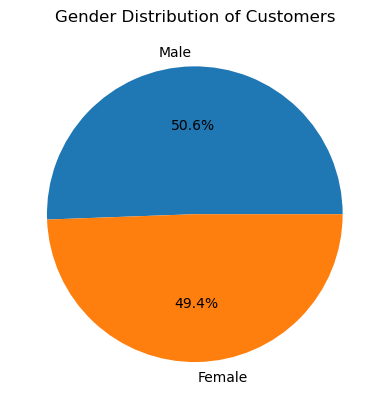

In [4]:
print(csps['Gender'].value_counts())
csps['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Gender Distribution of Customers')
plt.ylabel('')  
plt.show()

Country_x
United States     33767
United Kingdom     8140
Germany            5956
Canada             5415
Australia          2941
Italy              2685
Netherlands        2250
France             1730
Name: count, dtype: int64


Text(0, 0.5, 'customers')

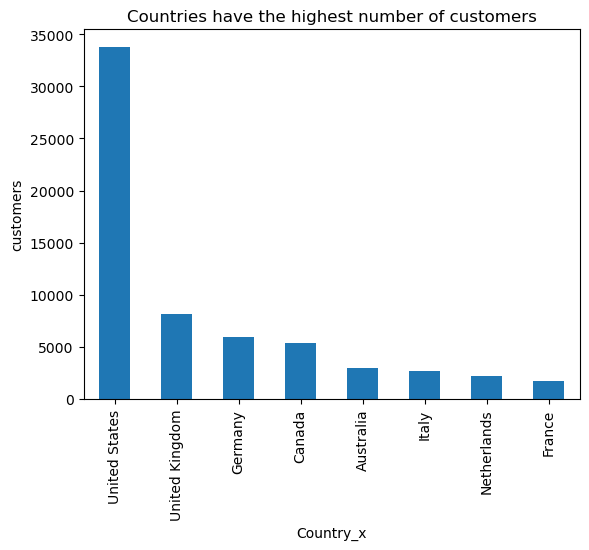

In [5]:
print(csps['Country_x'].value_counts())
csps['Country_x'].value_counts().plot(kind='bar')
plt.title('Countries have the highest number of customers')
plt.ylabel('customers')

Gender          Female   Male
Country_x                    
Australia         1553   1388
Canada            2695   2720
France             926    804
Germany           3084   2872
Italy             1294   1391
Netherlands       1077   1173
United Kingdom    4024   4116
United States    16427  17340


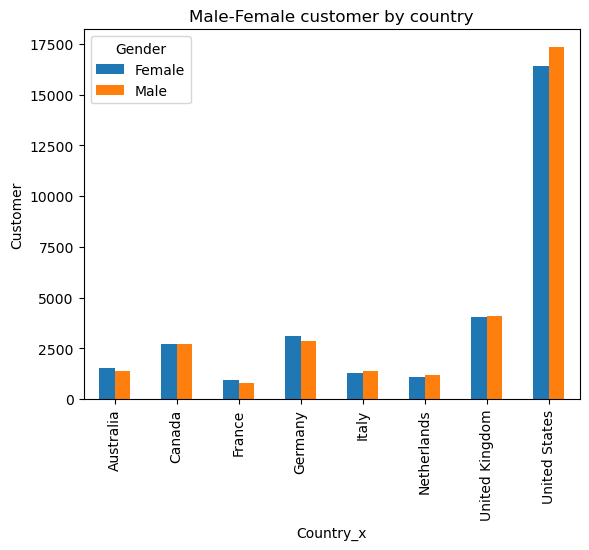

In [106]:
country_gender=pd.crosstab(csps['Country_x'],csps['Gender'])
print(country_gender)
country_gender.plot(kind='bar')
plt.title('Male-Female customer by country')
plt.ylabel('Customer')
plt.show()

In [145]:
Avarage_age=round(csps.groupby(['Country_x','Gender']).agg({'Age':'mean'}),2)
print(Avarage_age)


                         Age
Country_x      Gender       
Australia      Female  49.97
               Male    50.33
Canada         Female  49.11
               Male    49.12
France         Female  50.42
               Male    50.71
Germany        Female  50.67
               Male    49.58
Italy          Female  47.92
               Male    49.92
Netherlands    Female  49.78
               Male    49.36
United Kingdom Female  48.39
               Male    48.93
United States  Female  50.20
               Male    50.87


            Profit
Gender            
Female  5093026.88
Male    5239872.98


Text(0, 0.5, 'Revenue')

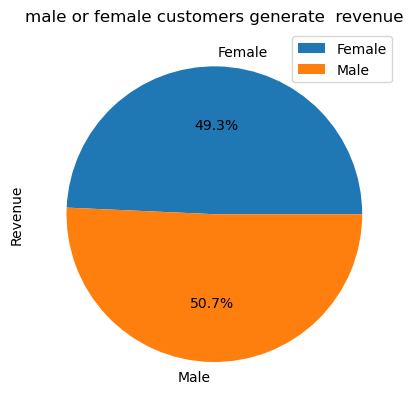

In [156]:
revenue=round(csps.groupby('Gender').agg({'Profit':'sum'}),2)
print(revenue)
revenue.plot(kind='pie',subplots=True,autopct='%1.1f%%')
plt.title('male or female customers generate  revenue')
plt.ylabel('Revenue')

In [7]:
csps['City'].value_counts().head(10)

City
Toronto         683
Los Angeles     579
New York        569
Houston         448
Chicago         385
Philadelphia    382
Montreal        361
Dallas          289
Calgary         267
Atlanta         248
Name: count, dtype: int64

In [10]:

sumoforder=csps['Order Date'].count()
sumoforder

np.int64(62884)

7.What age group purchases the most electronics?

C:\Users\HP\AppData\Local\Temp\ipykernel_22848\4118655107.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_orders = electronics.groupby('AgeGroup')['Order Date'].count().sort_values(ascending=False)


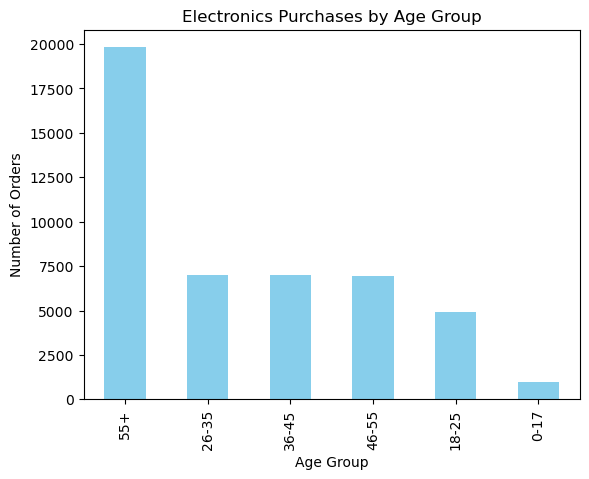

In [5]:
csps['Age']=round((csps['Order Date']-csps['Birthday']).dt.days/365,2)
bins=[0,18,25,35,45,55,100]
labels=['0-17','18-25','26-35','36-45', '46-55', '55+']
csps['AgeGroup'] = pd.cut(csps['Age'], bins=bins, labels=labels, right=False)
electronics_categories = [
    'Audio',
    'Computers',
    'Cameras and camcorders',
    'TV and Video',
    'Cell phones',
    'Home Appliances'
]

csps['IsElectronics'] = csps['Category'].isin(electronics_categories)
electronics = csps[csps['IsElectronics']]
age_group_orders = electronics.groupby('AgeGroup')['Order Date'].count().sort_values(ascending=False)

age_group_orders.plot(kind='bar', color='skyblue')
plt.title("Electronics Purchases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Orders")
plt.show()



8.Are certain products more popular among specific genders?


Category      Audio  Cameras and camcorders  Cell phones  Computers  \
Gender                                                                
Female    11.731017                9.140927    16.148649  22.181467   
Male      12.083386                8.546095    16.158345  22.421708   

Category  Games and Toys  Home Appliances  Music, Movies and Audio Books  \
Gender                                                                     
Female         11.180824         9.259974                      14.871300   
Male           11.275311         9.391900                      14.296944   

Category  TV and Video  
Gender                  
Female        5.485843  
Male          5.826311  


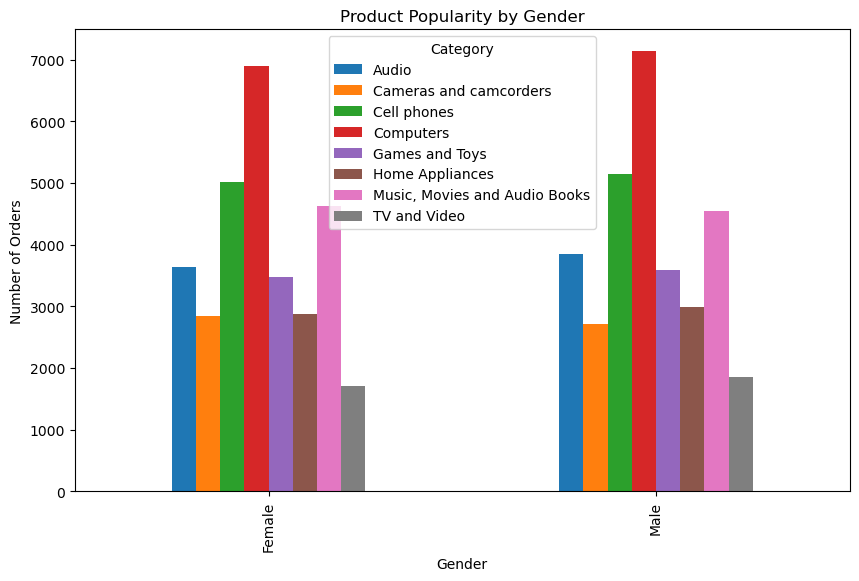

In [43]:
print(pd.crosstab(csps['Gender'],csps['Category'],normalize='index')*100)
pd.crosstab(csps['Gender'], csps['Category']).plot(kind='bar', figsize=(10,6))
plt.title("Product Popularity by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Orders")
plt.show()


 Sales & Order Analysis
1.What is the total global sales value (in USD)?
2.How do sales trend over time (monthly or yearly)?
3.Which countries generate the highest revenue?
4.What is the average order quantity per customer?

1.What is the total global sales value (in USD)?

In [6]:
csps.head(10)
csps['Sales']=csps['Unit Price USD']*csps['Quantity']
csps['Sales'].sum()

np.float64(55755479.59)

2.How do sales trend over time (monthly or yearly)?

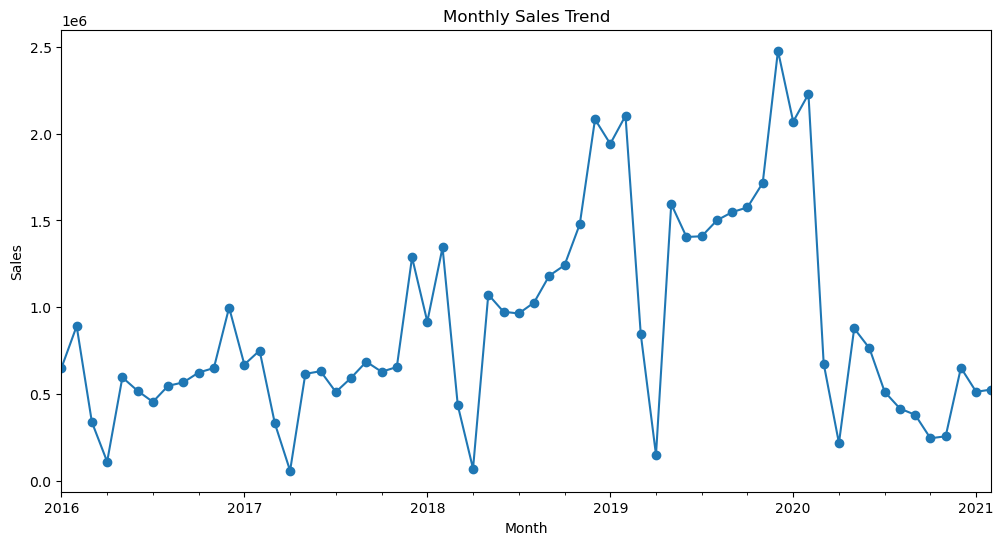

In [56]:
monthly_sales=csps.groupby(csps['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(kind='line',marker='o',figsize=(12,6))
plt.title("Monthly Sales Trend")
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

3.Which countries generate the highest revenue?

In [7]:
country_revenue=csps.groupby('Country_x')['Sales'].sum().sort_values(ascending=False)
print(country_revenue.head(10))

Country_x
United States     29871631.17
United Kingdom     7084088.12
Germany            5414149.80
Canada             4724334.63
Australia          2708137.61
Italy              2475645.77
Netherlands        1962154.27
France             1515338.22
Name: Sales, dtype: float64


4.What is the average order quantity per customer?

In [66]:
avg_order_qty=csps.groupby('CustomerKey')['Quantity'].sum().mean()
print(' the average order quantity per customer',round(avg_order_qty,2))

 the average order quantity per customer 16.64


 Product & Category Analysis
1.Which products generate the highest revenue?
2.Which product categories are most profitable?
3.What are the top 10 best-selling products by quantity?
4.Which brands perform best in terms of revenue?
5.What is the profit margin by product category?
6.Do higher-priced products sell less in quantity?


1.Which products generate the highest revenue?

In [32]:
Revenue=csps.groupby('Subcategory')['Sales'].sum().sort_values(ascending=False)
print(Revenue.head(10))


Subcategory
Desktops                9906356.50
Televisions             4308719.19
Projectors & Screens    3767522.00
Water Heaters           3547822.50
Camcorders              3357990.00
Laptops                 3164777.20
Movie DVD               3131006.44
Touch Screen Phones     3083462.00
Smart phones & PDAs     2805657.00
Refrigerators           2152664.41
Name: Sales, dtype: float64


2.Which product categories are most profitable?

Category
Computers                        3549191.65
Home Appliances                  1978211.56
Cameras and camcorders           1244672.64
Cell phones                      1128935.55
TV and Video                     1119499.64
Music, Movies and Audio Books     603267.22
Audio                             583859.06
Games and Toys                    125262.54
Name: Profit, dtype: float64


<Axes: xlabel='Category'>

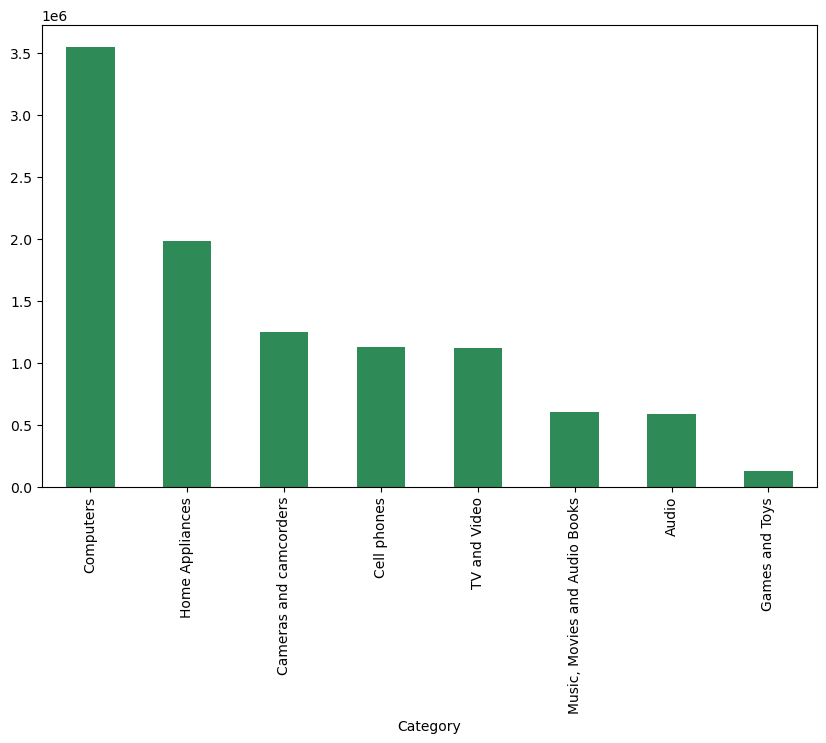

In [19]:
Profit=csps.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(Profit)
Profit.plot(kind='bar',figsize=(10,6),color='seagreen')

3.What are the top 10 best-selling products by quantity?

In [24]:
best_selling=csps.groupby('Subcategory')['Quantity'].count().sort_values(ascending=False)
print(best_selling.head(10))

Subcategory
Movie DVD               9169
Desktops                6447
Bluetooth Headphones    4327
Download Games          3606
Boxed Games             3455
Touch Screen Phones     3391
Smart phones & PDAs     3302
Recording Pen           2110
Televisions             1795
Home & Office Phones    1752
Name: Quantity, dtype: int64


4.Which brands perform best in terms of revenue?

In [25]:
brand_revenue=csps.groupby('Brand')['Sales'].sum().sort_values(ascending=False)
print(brand_revenue)

Brand
Adventure Works         11849909.32
Contoso                 10792325.32
Wide World Importers     9172800.41
Fabrikam                 6807893.52
The Phone Company        5386820.00
Proseware                3212628.02
Litware                  2659498.78
Southridge Video         2578595.93
A. Datum                 1486207.80
Northwind Traders        1126069.54
Tailspin Toys             682730.95
Name: Sales, dtype: float64


5.What is the profit margin by product category?

In [31]:
cat_summary=csps.groupby('Category')[['Profit','Sales']].sum()
cat_summary['Profitmargin']=(cat_summary['Profit']/cat_summary['Sales'])*100
cat_margin=cat_summary.sort_values('Profitmargin',ascending=False)
print(cat_margin)

                                   Profit        Sales  Profitmargin
Category                                                            
Music, Movies and Audio Books   603267.22   3131006.44     19.267518
Cameras and camcorders         1244672.64   6520168.02     19.089579
TV and Video                   1119499.64   5928982.69     18.881817
Audio                           583859.06   3169627.74     18.420430
Computers                      3549191.65  19301595.46     18.388074
Home Appliances                1978211.56  10795478.59     18.324445
Cell phones                    1128935.55   6183791.22     18.256366
Games and Toys                  125262.54    724829.43     17.281658


6.Do higher-priced products sell less in quantity

                                    AvgPrice  TotalQuantity
Subcategory                                                
Air Conditioners                  382.079744            884
Bluetooth Headphones              101.371241          13653
Boxed Games                         8.337728          11044
Camcorders                        752.212402           4482
Cameras & Camcorders Accessories   91.815741           4512
Car Video                         428.771363           1363
Cell phones Accessories            24.360169           5338
Correlation between price and quantity: -0.26351105822122983


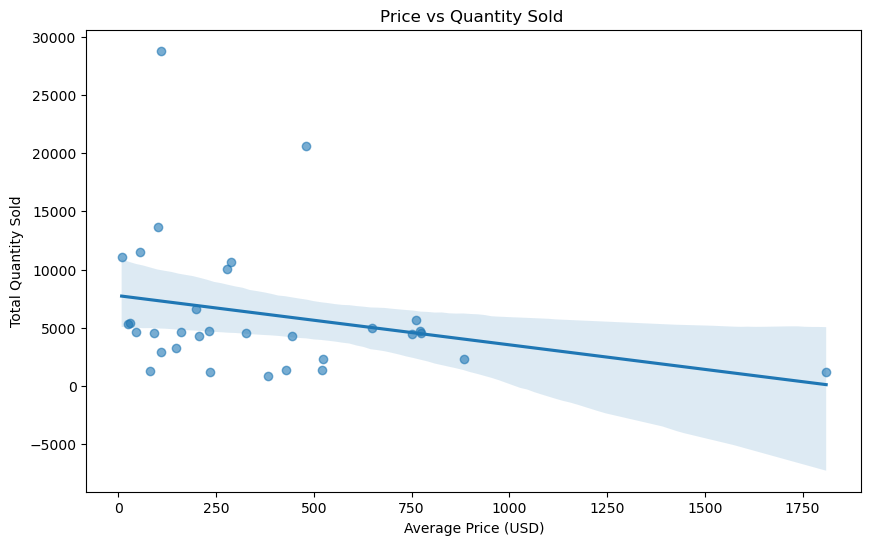

In [40]:
product_sales = csps.groupby('Subcategory')['Quantity'].sum()
product_prices = csps.groupby('Subcategory')['Unit Price USD'].mean()
price_vs_qty = pd.DataFrame({
    'AvgPrice': product_prices,
    'TotalQuantity': product_sales
})

print(price_vs_qty.head(7))
correlation = price_vs_qty['AvgPrice'].corr(price_vs_qty['TotalQuantity'])
print("Correlation between price and quantity:", correlation)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.regplot(x='AvgPrice', y='TotalQuantity', data=price_vs_qty, scatter_kws={'alpha':0.6})
plt.title("Price vs Quantity Sold ")
plt.xlabel("Average Price (USD)")
plt.ylabel("Total Quantity Sold")
plt.show()



Store Performance Analysis
1.Which countries stores generate the highest sales?
2.Do newer stores perform better than older ones?
3️. How do seasonal trends affect store performance?

1.Which countries stores generate the highest sales?

In [49]:
country_store_sales = csps.groupby('Country_y')['Sales'].sum().sort_values(ascending=False)
print(country_store_sales.head(10))  
country_state_sales = csps.groupby(['Country_y','State_y'])['Sales'].sum().sort_values(ascending=False)

print(country_state_sales.head(10))



Country_y
United States     23764425.86
Online            11404324.63
United Kingdom     5749769.78
Germany            4246279.22
Canada             3611561.79
Australia          2099141.07
Italy              2059086.81
Netherlands        1591344.48
France             1229545.95
Name: Sales, dtype: float64
Country_y      State_y              
Online         Online                   11404324.63
United States  Nevada                    1417885.41
               Kansas                    1394738.06
               Nebraska                  1384396.24
Canada         Northwest Territories     1336150.06
United States  New Mexico                1325611.89
               Connecticut               1318787.92
               South Carolina            1305684.43
               Oregon                    1302272.44
               Washington DC             1259350.98
Name: Sales, dtype: float64


2.Do newer stores perform better than older ones?

                Sales   StoreAge
StoreKey                        
0         11404324.63   9.036021
1           243029.93  11.105160
2            15175.99   8.143075
4           442475.02   8.786962
5           859678.19   3.012845


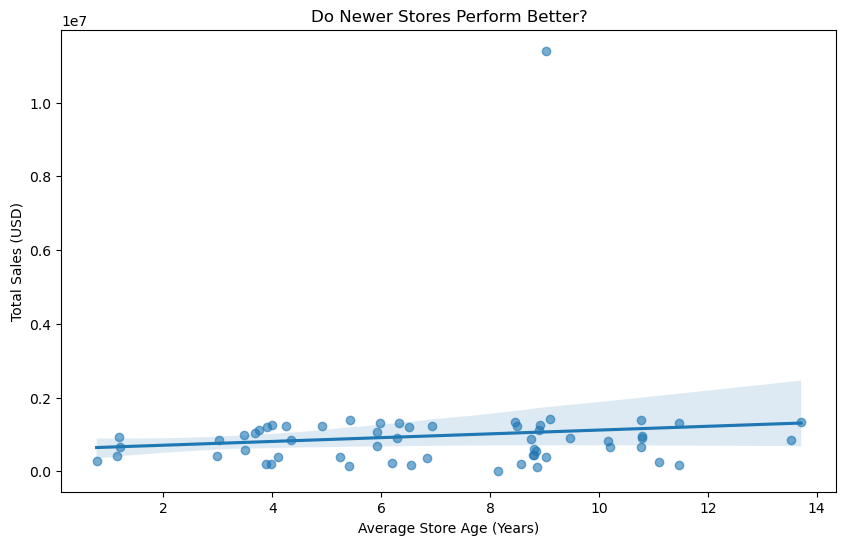

In [57]:
from datetime import datetime

csps['Open Date'] = pd.to_datetime(csps['Open Date'])
csps['Order Date'] = pd.to_datetime(csps['Order Date'])
csps['StoreAge'] = (csps['Order Date'] - csps['Open Date']).dt.days / 365
store_sales_age = csps.groupby('StoreKey').agg({
    'Sales':'sum',
    'StoreAge':'mean'
})

print(store_sales_age.head())
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.regplot(x='StoreAge', y='Sales', data=store_sales_age, scatter_kws={'alpha':0.6})
plt.title("Do Newer Stores Perform Better?")
plt.xlabel("Average Store Age (Years)")
plt.ylabel("Total Sales (USD)")
plt.show()


3️. How do seasonal trends affect store performance?

Month      2016-01   2016-02   2016-03   2016-04   2016-05   2016-06  \
StoreKey                                                               
0         68194.13  97945.22  22409.49  15898.22  52770.82  89869.50   
1             0.00      0.00      0.00      0.00      0.00   1837.50   
2          3846.85      0.00   8969.61   2359.53      0.00      0.00   
4          1914.90  13458.64      0.00   3004.89   6085.90   1582.00   
5         20142.69  36520.89      0.00  11180.91   3663.79    527.98   

Month       2016-07   2016-08   2016-09    2016-10  ...    2020-05    2020-06  \
StoreKey                                            ...                         
0         132598.46  83904.71  75340.06  146573.31  ...  211634.96  188883.20   
1              0.00   2816.40   4587.68       0.00  ...       0.00    4260.74   
2              0.00      0.00      0.00       0.00  ...       0.00       0.00   
4              0.00      0.00   1882.56     917.34  ...    5522.19    5779.61   
5        

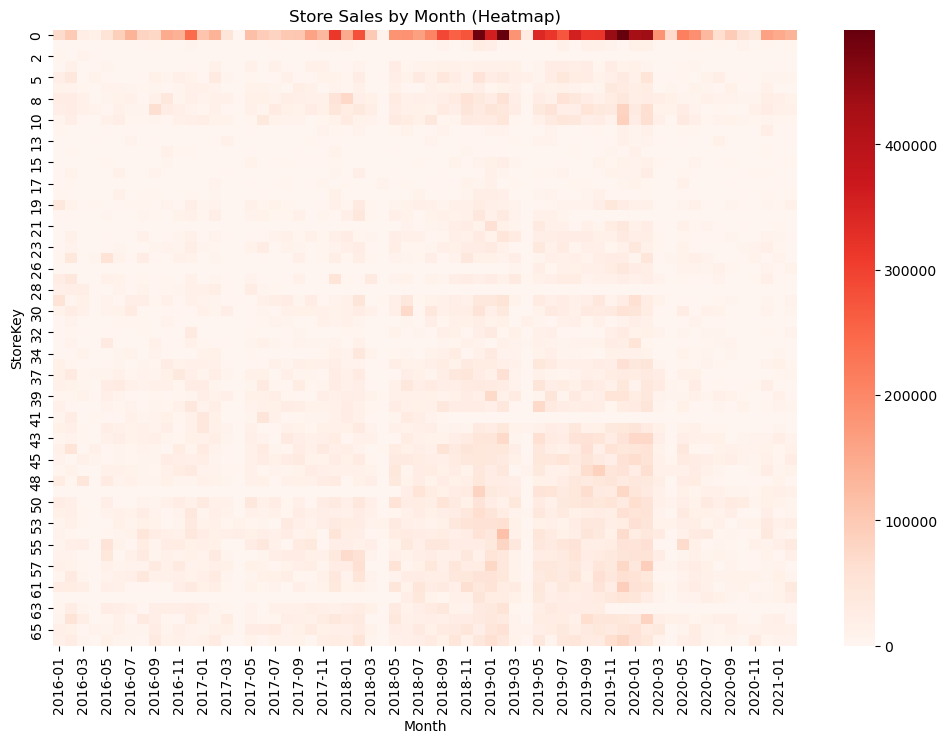

In [62]:
csps['Order Date'] = pd.to_datetime(csps['Order Date'])
csps['Month'] = csps['Order Date'].dt.to_period('M')

seasonal_sales = csps.groupby(['StoreKey','Month'])['Sales'].sum().unstack().fillna(0)
print(seasonal_sales.head())


plt.figure(figsize=(12,8))
sns.heatmap(seasonal_sales, cmap="Reds")
plt.title("Store Sales by Month (Heatmap)")
plt.xlabel("Month")
plt.ylabel("StoreKey")
plt.show()
